In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
# All files are located in the 'results' folder


df_results = pd.read_excel("results/results_unet3d_original.xlsx")
df_results_new = pd.read_excel("results/results_unet3d_new.xlsx")
df_results_ensemble = pd.read_excel("results/results_unet3d_ensemble.xlsx")


Some of the code in this notebook pertaining to statistical analysis was generated with GitHub Copilot and subsequently reviewed for correctness and suitability.

In [2]:
df_results.columns

Index(['Patient', 'MAE', 'SD', 'MedAE', 'IQR', 'RMSE', 'Cosine', 'Angle',
       'SD.1', 'MedAngle', 'IQR.1', 'Count'],
      dtype='object')

In [3]:
df_results

,Patient,MAE,SD,MedAE,IQR,RMSE,Cosine,Angle,SD.1,MedAngle,IQR.1,Count
0,2,1.525,0.719,1.450,1.272,1.686,-0.225,104.99,31.20,112.80,54.28,9
1,3,1.057,1.015,0.658,1.596,1.465,-0.067,94.04,11.94,87.50,15.41,9
2,4,1.348,0.542,1.432,0.669,1.453,-0.870,151.90,9.47,151.64,17.31,9
3,5,0.959,0.615,0.945,0.402,1.139,-0.620,129.62,12.96,126.29,13.61,9
4,6,0.915,0.638,1.032,1.074,1.115,0.569,52.09,24.04,45.90,29.75,9
5,7,0.700,0.556,0.511,0.461,0.893,-0.164,99.53,9.39,103.37,8.12,7
6,8,0.947,0.714,0.778,0.978,1.186,-0.039,92.73,21.55,82.18,30.87,9
7,9,1.312,0.580,1.439,0.524,1.435,0.147,81.23,13.97,88.19,22.73,9
8,10,1.310,0.857,1.310,0.857,1.565,-0.681,138.28,24.19,138.28,24.19,2
9,11,1.958,1.491,1.762,0.502,2.462,-0.128,98.50,24.34,91.38,30.68,9


In [4]:
df_results['PatientSort'] = df_results['Patient'].astype(int)
df_results_new['PatientSort'] = df_results_new['Patient'].astype(int)
df_results_ensemble['PatientSort'] = df_results_ensemble['Patient'].astype(int)

df_results = df_results.sort_values('PatientSort').drop(columns='PatientSort')
df_results_new = df_results_new.sort_values('PatientSort').drop(columns='PatientSort')
df_results_ensemble = df_results_ensemble.sort_values('PatientSort').drop(columns='PatientSort')

In [19]:
from scipy.stats import wilcoxon, friedmanchisquare
import pandas as pd
import numpy as np

def hodges_lehmann_ci(x, y, alpha=0.05, max_iter=50, tol=1e-4):
    """
    Hodges–Lehmann estimator and ~95% CI by inverting the Wilcoxon test.
    CI is for the median paired difference (x - y).
    """
    x = np.asarray(x)
    y = np.asarray(y)
    diffs = x - y

    # HL point estimate: median of paired differences
    hl = np.median(diffs)

    # If all differences are basically zero, CI is [0, 0]
    if np.allclose(diffs, 0):
        return hl, (0.0, 0.0)

    min_diff = float(np.min(diffs))
    max_diff = float(np.max(diffs))
    target = alpha

    def p_val(delta):
        # Test H0: median(diffs) = delta
        # i.e., Wilcoxon on (diffs - delta) with H0: median = 0
        try:
            _, p = wilcoxon(diffs - delta)
        except ValueError:
            # e.g., all zero after shift → no variation
            p = 1.0
        return p

    def find_bound(lo, hi):
        """
        Binary search on [lo, hi] for delta where p(delta) ≈ alpha.
        Assumes p is largest near HL and decreases toward the edges.
        """
        p_lo = p_val(lo) - target
        p_hi = p_val(hi) - target

        # If we can't bracket a root, just return the endpoint
        if p_lo * p_hi > 0:
            return lo if abs(p_lo) < abs(p_hi) else hi

        for _ in range(max_iter):
            mid = 0.5 * (lo + hi)
            p_mid = p_val(mid) - target

            if abs(hi - lo) < tol:
                break

            if p_lo * p_mid <= 0:
                hi, p_hi = mid, p_mid
            else:
                lo, p_lo = mid, p_mid

        # Return the point in [lo, hi] with p >= alpha if possible
        # (approximate boundary of CI)
        if p_val(lo) >= target:
            return lo
        elif p_val(hi) >= target:
            return hi
        else:
            # fallback
            return lo

    # Lower bound: between min_diff and HL
    lower = find_bound(min_diff, hl)

    # Upper bound: between HL and max_diff
    upper = find_bound(hl, max_diff)

    return hl, (lower, upper)


def print_results(metric, values_orig, values_new, values_ensemble):
    print(f"\n Metric: {metric}")

    # Convert to numpy arrays
    v1 = np.asarray(values_orig)
    v2 = np.asarray(values_new)
    v3 = np.asarray(values_ensemble)

    # Mean ± SD
    print(f"Mean ± SD — Baseline: {v1.mean():.4f} ± {v1.std(ddof=0):.4f}")
    print(f"Mean ± SD — Enhanced: {v2.mean():.4f} ± {v2.std(ddof=0):.4f}")
    print(f"Mean ± SD — Ensemble: {v3.mean():.4f} ± {v3.std(ddof=0):.4f}")

    # NEW: Median [IQR]
    def median_iqr(arr):
        med = np.median(arr)
        q1 = np.percentile(arr, 25)
        q3 = np.percentile(arr, 75)
        return med, (q3 - q1)

    med1, iqr1 = median_iqr(v1)
    med2, iqr2 = median_iqr(v2)
    med3, iqr3 = median_iqr(v3)

    print(f"Median [IQR] — Baseline: {med1:.4f} [{iqr1:.4f}]")
    print(f"Median [IQR] — Enhanced: {med2:.4f} [{iqr2:.4f}]")
    print(f"Median [IQR] — Ensemble: {med3:.4f} [{iqr3:.4f}]")

    # Wilcoxon signed-rank tests
    try:
        stat1, p1 = wilcoxon(v1, v2)
        stat2, p2 = wilcoxon(v1, v3)
        stat3, p3 = wilcoxon(v2, v3)

        # Bonferroni correction
        p1_corr = min(p1 * 3, 1.0)
        p2_corr = min(p2 * 3, 1.0)
        p3_corr = min(p3 * 3, 1.0)

        print(f"Wilcoxon: Baseline vs Enhanced p={p1:.4f} (corrected={p1_corr:.4f})")
        print(f"Wilcoxon: Baseline vs Ensemble p={p2:.4f} (corrected={p2_corr:.4f})")
        print(f"Wilcoxon: Enhanced vs Ensemble p={p3:.4f} (corrected={p3_corr:.4f})")

        # Hodges–Lehmann estimates + CIs (paired, consistent with Wilcoxon)
        hl1, ci1 = hodges_lehmann_ci(v1, v2)
        hl2, ci2 = hodges_lehmann_ci(v1, v3)
        hl3, ci3 = hodges_lehmann_ci(v2, v3)

        print(f"HL (Baseline - Enhanced): {hl1:.4f}, CI 95%: ({ci1[0]:.4f}, {ci1[1]:.4f})")
        print(f"HL (Baseline - Ensemble): {hl2:.4f}, CI 95%: ({ci2[0]:.4f}, {ci2[1]:.4f})")
        print(f"HL (Enhanced - Ensemble): {hl3:.4f}, CI 95%: ({ci3[0]:.4f}, {ci3[1]:.4f})")

    except ValueError as e:
        print("Wilcoxon Error:", e)

    # Friedman test
    try:
        stat, p = friedmanchisquare(v1, v2, v3)
        print(f"Friedman test: p={p:.4f}")
    except ValueError as e:
        print("Friedman Error:", e)


# All metrics to analyze
metrics = ['MAE', 'MedAE', 'Angle', 'MedAngle', 'RMSE', 'Cosine']
secondary_metrics = ['SD', 'IQR', 'SD.1', 'IQR.1']  # still available if you want them

# df_results, df_results_new, df_results_ensemble assumed already defined
for metric in metrics:
    vals1 = df_results[metric]
    vals2 = df_results_new[metric]
    vals3 = df_results_ensemble[metric]
    print_results(metric, vals1, vals2, vals3)



 Metric: MAE
Mean ± SD — Baseline: 1.7052 ± 1.6711
Mean ± SD — Enhanced: 2.7642 ± 2.2171
Mean ± SD — Ensemble: 2.1753 ± 1.9538
Median [IQR] — Baseline: 1.3100 [0.5660]
Median [IQR] — Enhanced: 1.9170 [1.5440]
Median [IQR] — Ensemble: 1.6380 [1.2270]
Wilcoxon: Baseline vs Enhanced p=0.0046 (corrected=0.0139)
Wilcoxon: Baseline vs Ensemble p=0.0681 (corrected=0.2043)
Wilcoxon: Enhanced vs Ensemble p=0.0215 (corrected=0.0645)
HL (Baseline - Enhanced): -0.6970, CI 95%: (-1.6950, -0.3090)
HL (Baseline - Ensemble): -0.2890, CI 95%: (-0.9414, 0.0750)
HL (Enhanced - Ensemble): 0.8970, CI 95%: (0.2730, 1.1140)
Friedman test: p=0.0023

 Metric: MedAE
Mean ± SD — Baseline: 1.6390 ± 1.7077
Mean ± SD — Enhanced: 2.5766 ± 2.3054
Mean ± SD — Ensemble: 2.1049 ± 2.0089
Median [IQR] — Baseline: 1.3100 [0.5730]
Median [IQR] — Enhanced: 1.5860 [1.6400]
Median [IQR] — Ensemble: 1.5940 [1.5720]
Wilcoxon: Baseline vs Enhanced p=0.0479 (corrected=0.1436)
Wilcoxon: Baseline vs Ensemble p=0.1465 (corrected=0.4

In [6]:
df_results 

,Patient,MAE,SD,MedAE,IQR,RMSE,Cosine,Angle,SD.1,MedAngle,IQR.1,Count
0,2,1.525,0.719,1.450,1.272,1.686,-0.225,104.99,31.20,112.80,54.28,9
1,3,1.057,1.015,0.658,1.596,1.465,-0.067,94.04,11.94,87.50,15.41,9
2,4,1.348,0.542,1.432,0.669,1.453,-0.870,151.90,9.47,151.64,17.31,9
3,5,0.959,0.615,0.945,0.402,1.139,-0.620,129.62,12.96,126.29,13.61,9
4,6,0.915,0.638,1.032,1.074,1.115,0.569,52.09,24.04,45.90,29.75,9
5,7,0.700,0.556,0.511,0.461,0.893,-0.164,99.53,9.39,103.37,8.12,7
6,8,0.947,0.714,0.778,0.978,1.186,-0.039,92.73,21.55,82.18,30.87,9
7,9,1.312,0.580,1.439,0.524,1.435,0.147,81.23,13.97,88.19,22.73,9
8,10,1.310,0.857,1.310,0.857,1.565,-0.681,138.28,24.19,138.28,24.19,2
9,11,1.958,1.491,1.762,0.502,2.462,-0.128,98.50,24.34,91.38,30.68,9


In [7]:
def plot_comparison(df1, df2, df3, metric, error_col, title):
    import numpy as np
    import matplotlib.pyplot as plt

    x = list(df1['Patient'])  # No 'Overall'
    num_patients = len(df1)
    x_indices = np.arange(num_patients)
    width = 0.23
    z_score = 1.96  # 95% CI

    # Margin of error for per-patient values
    def get_moe(df):
        return z_score * (df[error_col] / np.sqrt(df['Count']))

    moe1 = get_moe(df1)
    moe2 = get_moe(df2)
    moe3 = get_moe(df3)

    y1 = df1[metric]
    y2 = df2[metric]
    y3 = df3[metric]

    fig, ax = plt.subplots(figsize=(len(x) * 1.2, 6))

    ax.bar(x_indices - width, y1, width, yerr=moe1, capsize=4, label='UNet3D-Baseline')
    ax.bar(x_indices,        y2, width, yerr=moe2, capsize=4, label='UNet3D-Enhanced')
    ax.bar(x_indices + width, y3, width, yerr=moe3, capsize=4, label='UNet3D-Ensemble')

    xtick_labels = [f"{int(p):02d}" for p in x]
    ax.set_xticks(x_indices)
    ax.set_xticklabels(xtick_labels)

    ax.set_xlabel('Patient ID')
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


In [8]:
def weighted_mean(series, weights):
    return np.average(series, weights=weights)

def pooled_std(std_series, weights):
    return np.sqrt(np.sum((weights * (std_series ** 2))) / np.sum(weights))

# Original results
mae_mean_orig = weighted_mean(df_results['MAE'], df_results['Count'])
mae_sd_orig = pooled_std(df_results['SD'], df_results['Count'])

angle_mean_orig = weighted_mean(df_results['Angle'], df_results['Count'])
angle_sd_orig = pooled_std(df_results['SD.1'], df_results['Count'])

# New results
mae_mean_new = weighted_mean(df_results_new['MAE'], df_results_new['Count'])
mae_sd_new = pooled_std(df_results_new['SD'], df_results_new['Count'])

angle_mean_new = weighted_mean(df_results_new['Angle'], df_results_new['Count'])
angle_sd_new = pooled_std(df_results_new['SD.1'], df_results_new['Count'])

# Ensemble results
mae_mean_ensemble = weighted_mean(df_results_ensemble['MAE'], df_results_ensemble['Count'])
mae_sd_ensemble = pooled_std(df_results_ensemble['SD'], df_results_ensemble['Count'])

angle_mean_ensemble = weighted_mean(df_results_ensemble['Angle'], df_results_ensemble['Count'])
angle_sd_ensemble = pooled_std(df_results_ensemble['SD.1'], df_results_ensemble['Count'])

print("Weighted Means and Pooled SDs:")
print(f"Original MAE Mean: {mae_mean_orig:.4f}, Pooled SD: {mae_sd_orig:.4f}")
print(f"Original Angle Mean: {angle_mean_orig:.4f}, Pooled SD: {angle_sd_orig:.4f}")
print(f"New MAE Mean: {mae_mean_new:.4f}, Pooled SD: {mae_sd_new:.4f}")
print(f"New Angle Mean: {angle_mean_new:.4f}, Pooled SD: {angle_sd_new:.4f}")
print(f"Ensemble MAE Mean: {mae_mean_ensemble:.4f}, Pooled SD: {mae_sd_ensemble:.4f}")
print(f"Ensemble Angle Mean: {angle_mean_ensemble:.4f}, Pooled SD: {angle_sd_ensemble:.4f}")

Weighted Means and Pooled SDs:
Original MAE Mean: 1.7494, Pooled SD: 0.8213
Original Angle Mean: 102.9059, Pooled SD: 20.8194
New MAE Mean: 2.8569, Pooled SD: 1.2071
New Angle Mean: 78.2844, Pooled SD: 21.0192
Ensemble MAE Mean: 2.2628, Pooled SD: 1.3015
Ensemble Angle Mean: 91.3904, Pooled SD: 24.3164


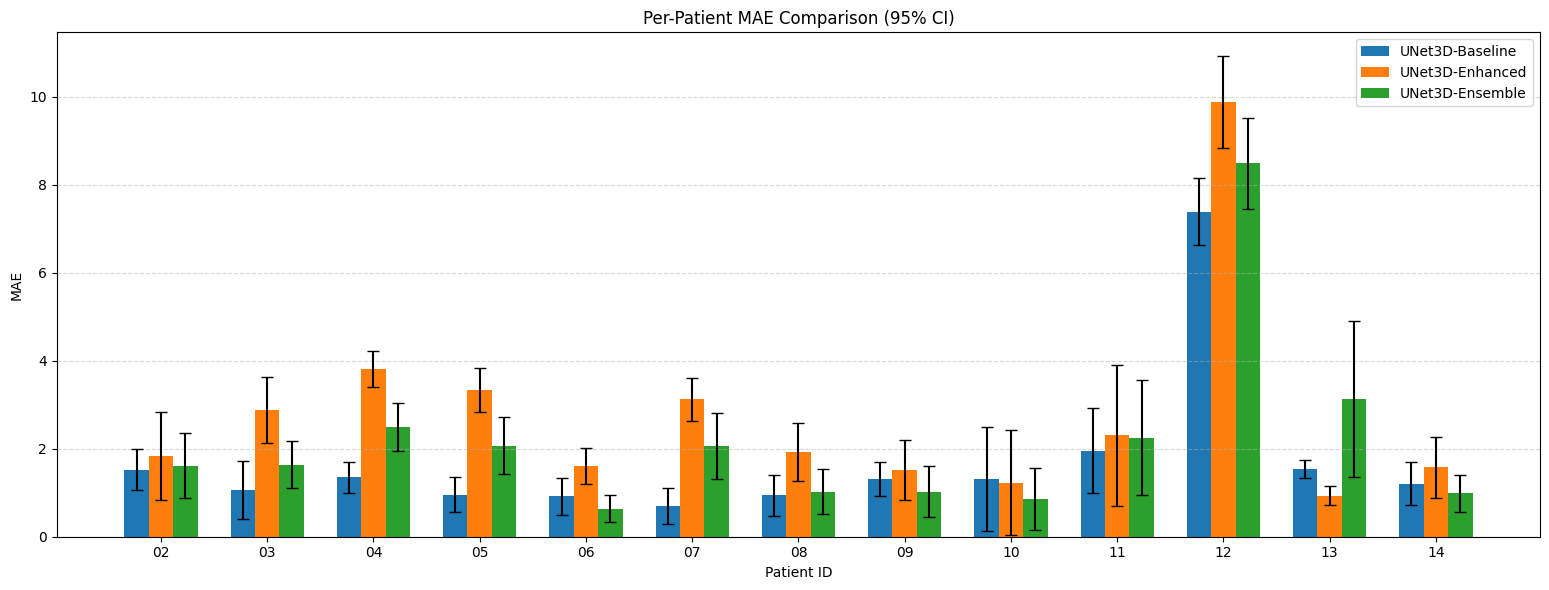

In [9]:
plot_comparison(
    df_results, df_results_new, df_results_ensemble,
    'MAE', 'SD',
    'Per-Patient MAE Comparison (95% CI)'
)


In [10]:
def plot_comparison_dot(df1, df2, df3, metric, error_col, title):
    import numpy as np
    import matplotlib.pyplot as plt

    z_score = 1.96  # for 95% CI

    x = list(df1['Patient'])
    x_indices = np.arange(len(x))
    xtick_labels = [f"{int(p):02d}" for p in x]

    y1 = np.array(df1[metric])
    y2 = np.array(df2[metric])
    y3 = np.array(df3[metric])

    def get_moe(df):
        return z_score * (df[error_col] / np.sqrt(df['Count']))

    moe1 = get_moe(df1).to_numpy()
    moe2 = get_moe(df2).to_numpy()
    moe3 = get_moe(df3).to_numpy()

    lower_y1 = np.maximum(0, y1 - moe1)
    lower_y2 = np.maximum(0, y2 - moe2)
    lower_y3 = np.maximum(0, y3 - moe3)

    upper_y1 = y1 + moe1
    upper_y2 = y2 + moe2
    upper_y3 = y3 + moe3

    fig, ax = plt.subplots(figsize=(len(x) * 1.2, 6))

    # Dot plots
    for i, (y, low, high) in enumerate(zip(y1, lower_y1, upper_y1)):
        ax.errorbar(x_indices[i] - 0.2, y, yerr=[[y - low], [high - y]],
                    fmt='o', markersize=6, capsize=4,
                    color='tab:blue', label='UNet3D-Baseline' if i == 0 else "")

    for i, (y, low, high) in enumerate(zip(y2, lower_y2, upper_y2)):
        ax.errorbar(x_indices[i], y, yerr=[[y - low], [high - y]],
                    fmt='s', markersize=6, capsize=4,
                    color='tab:orange', label='UNet3D-Enhanced' if i == 0 else "")

    for i, (y, low, high) in enumerate(zip(y3, lower_y3, upper_y3)):
        ax.errorbar(x_indices[i] + 0.2, y, yerr=[[y - low], [high - y]],
                    fmt='^', markersize=6, capsize=4,
                    color='tab:green', label='UNet3D-Ensemble' if i == 0 else "")

    ax.set_xticks(x_indices)
    ax.set_xticklabels(xtick_labels)
    ax.set_xlabel('Patient ID')
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


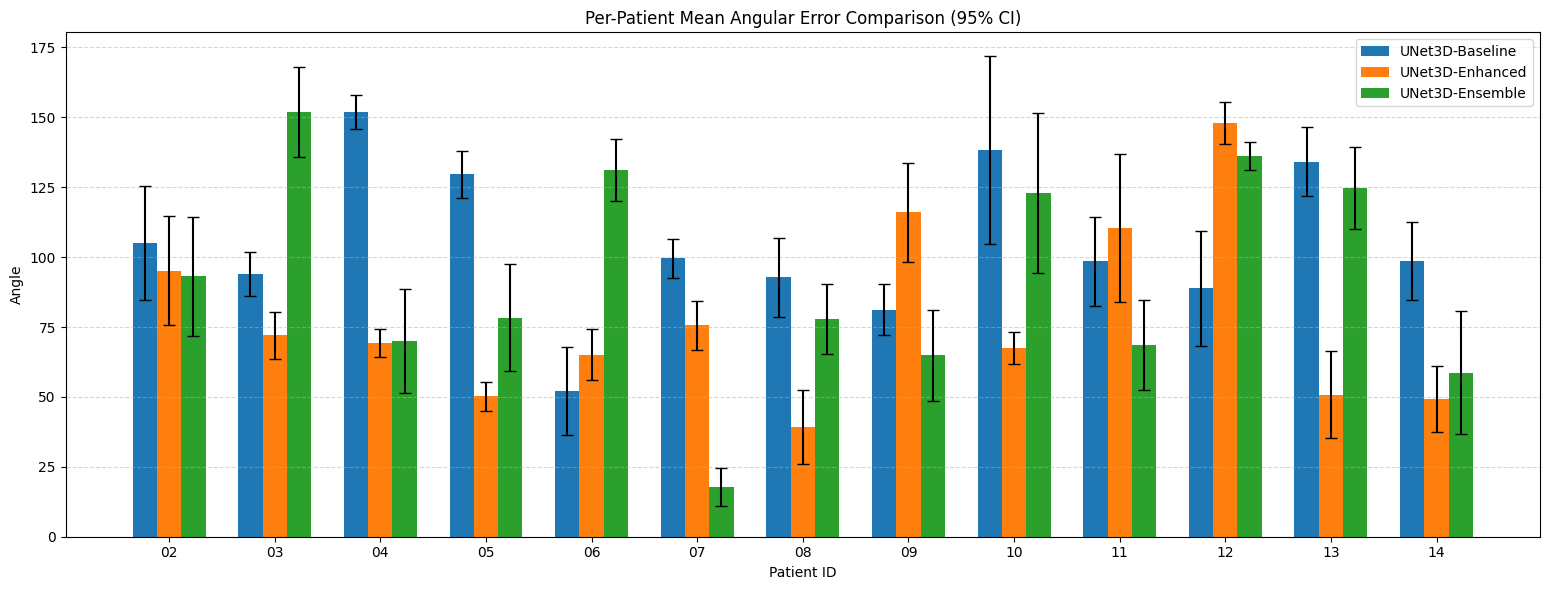

In [18]:

plot_comparison(
    df_results, df_results_new, df_results_ensemble,
    'Angle', 'SD.1',
    'Per-Patient Mean Angular Error Comparison (95% CI)'
)




In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_combined_mae_angle(df1, df2, df3):
    z_score = 1.96
    x = list(df1['Patient'])
    x_indices = np.arange(len(x))
    xtick_labels = [f"{int(p):02d}" for p in x]
    width = 0.23

    def get_moe(df, col): return z_score * (df[col] / np.sqrt(df['Count']))

    mae1 = df1['MAE'].to_numpy()
    mae2 = df2['MAE'].to_numpy()
    mae3 = df3['MAE'].to_numpy()
    moe_mae1 = get_moe(df1, 'SD')
    moe_mae2 = get_moe(df2, 'SD')
    moe_mae3 = get_moe(df3, 'SD')

    angle1 = df1['Angle'].to_numpy()
    angle2 = df2['Angle'].to_numpy()
    angle3 = df3['Angle'].to_numpy()
    moe_angle1 = get_moe(df1, 'SD.1')
    moe_angle2 = get_moe(df2, 'SD.1')
    moe_angle3 = get_moe(df3, 'SD.1')

    lower_a1 = np.maximum(0, angle1 - moe_angle1)
    lower_a2 = np.maximum(0, angle2 - moe_angle2)
    lower_a3 = np.maximum(0, angle3 - moe_angle3)
    upper_a1 = angle1 + moe_angle1
    upper_a2 = angle2 + moe_angle2
    upper_a3 = angle3 + moe_angle3

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(len(x) * 1.1, 10), sharex=True)

    # Top: MAE Bar 
    ax1.bar(x_indices - width, mae1, width, yerr=moe_mae1, capsize=4, color='tab:blue', label='UNet3D-Baseline')
    ax1.bar(x_indices,        mae2, width, yerr=moe_mae2, capsize=4, color='tab:orange', label='UNet3D-Enhanced')
    ax1.bar(x_indices + width, mae3, width, yerr=moe_mae3, capsize=4, color='tab:green', label='UNet3D-Ensemble')

    ax1.set_ylabel("MAE (mm)")
    ax1.set_title("Per-Patient MAE Comparison (95% CI)")
    ax1.grid(axis='y', linestyle='--', alpha=0.5)
    ax1.legend()

    # Bottom: Angle Dot Plot 
    for i, (y, low, high) in enumerate(zip(angle1, lower_a1, upper_a1)):
        ax2.errorbar(x_indices[i] - 0.2, y, yerr=[[y - low], [high - y]],
                     fmt='o', markersize=6, capsize=4, color='tab:blue', label='UNet3D-Baseline' if i == 0 else "")
    for i, (y, low, high) in enumerate(zip(angle2, lower_a2, upper_a2)):
        ax2.errorbar(x_indices[i], y, yerr=[[y - low], [high - y]],
                     fmt='s', markersize=6, capsize=4, color='tab:orange', label='UNet3D-Enhanced' if i == 0 else "")
    for i, (y, low, high) in enumerate(zip(angle3, lower_a3, upper_a3)):
        ax2.errorbar(x_indices[i] + 0.2, y, yerr=[[y - low], [high - y]],
                     fmt='^', markersize=6, capsize=4, color='tab:green', label='UNet3D-Ensemble' if i == 0 else "")

    ax2.set_xticks(x_indices)
    ax2.set_xticklabels(xtick_labels)
    ax2.set_xlabel("Patient ID")
    ax2.set_ylabel("Angular Error (°)")
    ax2.set_title("Per-Patient Mean Angular Error (95% CI)")
    ax2.grid(axis='y', linestyle='--', alpha=0.5)
    ax2.legend()

    plt.tight_layout()
    plt.show()


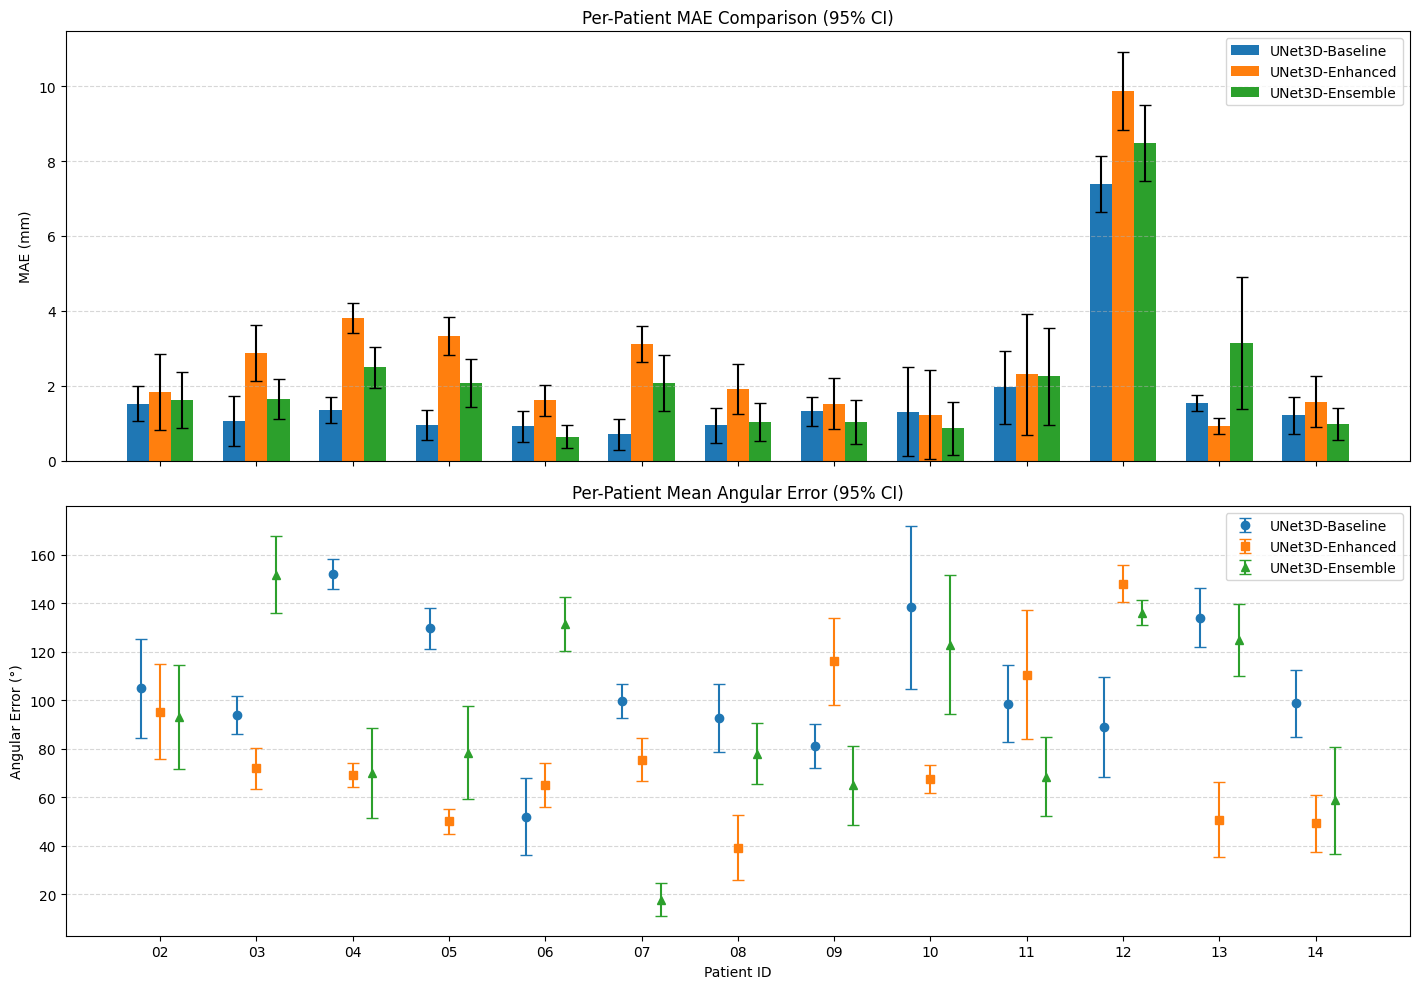

In [13]:
plot_combined_mae_angle(df_results, df_results_new, df_results_ensemble)


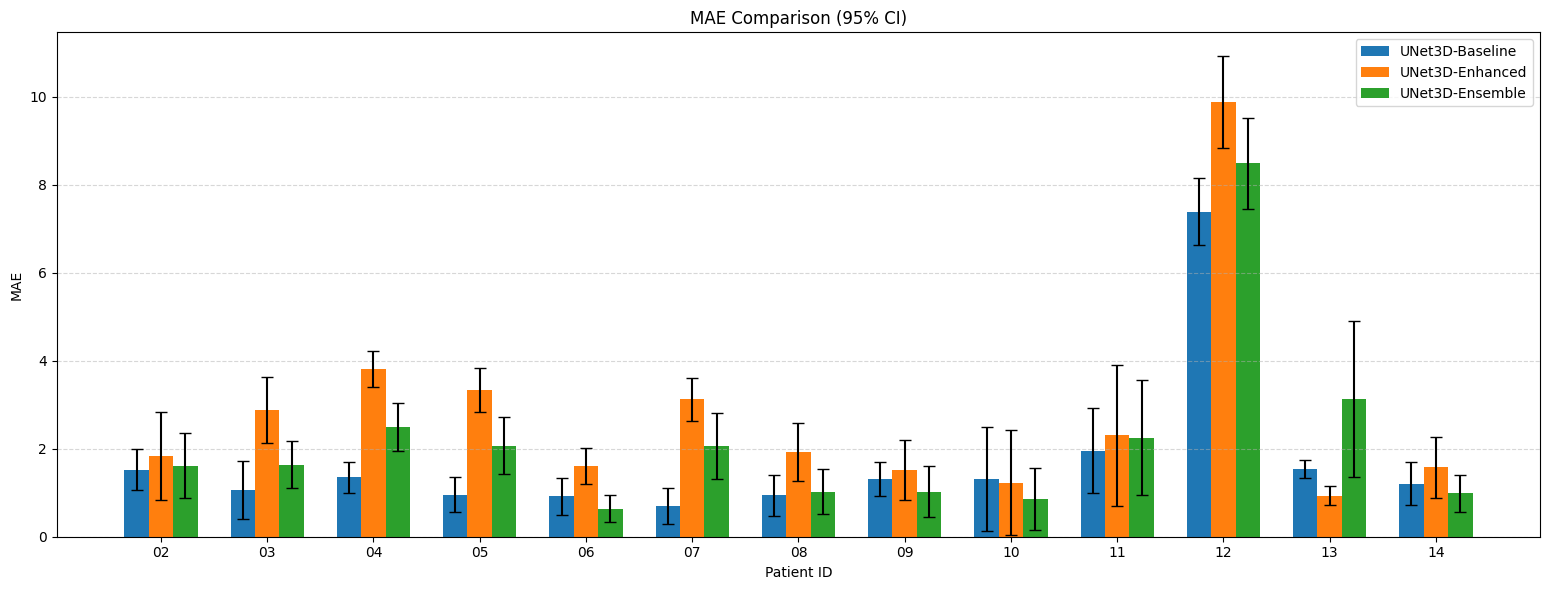

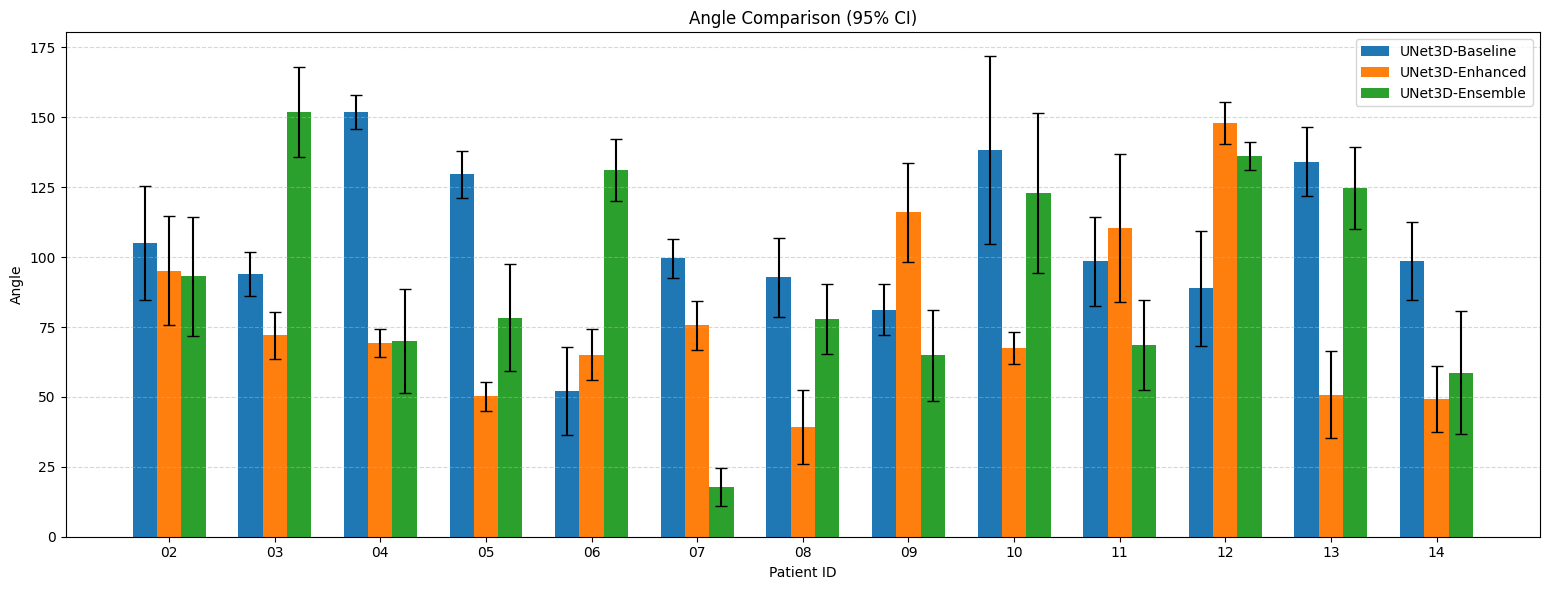

In [14]:
# MAE with SD error
plot_comparison(df_results, df_results_new, df_results_ensemble, 'MAE', 'SD', 'MAE Comparison (95% CI)')

plot_comparison(df_results, df_results_new, df_results_ensemble, 'Angle', 'SD.1', 'Angle Comparison (95% CI)')



In [15]:
def dot_plot_with_error(df1, df2, df3, metric, error_col, title):
    import matplotlib.pyplot as plt
    import numpy as np

    x = df1['Patient']
    num_patients = len(x)
    z = 1.96  # 95% CI

    x_indices = np.arange(len(x))

    fig, ax = plt.subplots(figsize=(num_patients * 1.2, 6))

    # margins of error
    def moe(df): return z * df[error_col] / np.sqrt(df['Count'])

    jitter = 0.15
    ax.errorbar(x_indices - jitter, df1[metric], yerr=moe(df1), fmt='o', label='Baseline', capsize=4)
    ax.errorbar(x_indices,          df2[metric], yerr=moe(df2), fmt='s', label='Enhanced', capsize=4)
    ax.errorbar(x_indices + jitter, df3[metric], yerr=moe(df3), fmt='^', label='Ensemble', capsize=4)

    ax.set_xticks(x_indices)
    ax.set_xticklabels(x)
    ax.set_xlabel('Patient')
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


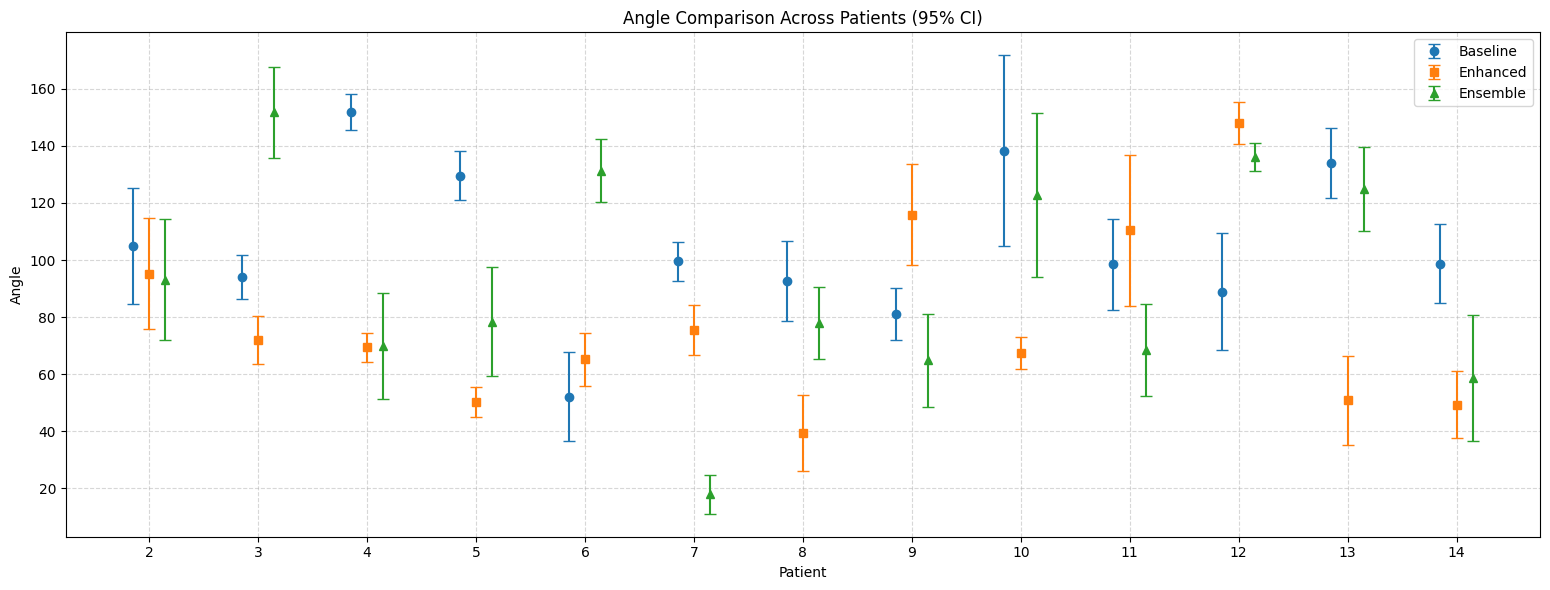

In [16]:
dot_plot_with_error(df_results, df_results_new, df_results_ensemble, 'Angle', 'SD.1', 'Angle Comparison Across Patients (95% CI)')


In [17]:
def weighted_mean(series, weights):
    return np.average(series, weights=weights)

def pooled_std(std_series, weights):
    return np.sqrt(np.sum((weights * (std_series ** 2))) / np.sum(weights))

# Original results
mae_mean_orig = weighted_mean(df_results['MAE'], df_results['Count'])
mae_sd_orig = pooled_std(df_results['SD'], df_results['Count'])

angle_mean_orig = weighted_mean(df_results['Angle'], df_results['Count'])
angle_sd_orig = pooled_std(df_results['SD.1'], df_results['Count'])

# New results
mae_mean_new = weighted_mean(df_results_new['MAE'], df_results_new['Count'])
mae_sd_new = pooled_std(df_results_new['SD'], df_results_new['Count'])

angle_mean_new = weighted_mean(df_results_new['Angle'], df_results_new['Count'])
angle_sd_new = pooled_std(df_results_new['SD.1'], df_results_new['Count'])

# Ensemble results
mae_mean_ensemble = weighted_mean(df_results_ensemble['MAE'], df_results_ensemble['Count'])
mae_sd_ensemble = pooled_std(df_results_ensemble['SD'], df_results_ensemble['Count'])

angle_mean_ensemble = weighted_mean(df_results_ensemble['Angle'], df_results_ensemble['Count'])
angle_sd_ensemble = pooled_std(df_results_ensemble['SD.1'], df_results_ensemble['Count'])

print("Weighted Means and Pooled SDs:")
print(f"Original MAE Mean: {mae_mean_orig:.4f}, Pooled SD: {mae_sd_orig:.4f}")
print(f"Original Angle Mean: {angle_mean_orig:.4f}, Pooled SD: {angle_sd_orig:.4f}")
print(f"New MAE Mean: {mae_mean_new:.4f}, Pooled SD: {mae_sd_new:.4f}")
print(f"New Angle Mean: {angle_mean_new:.4f}, Pooled SD: {angle_sd_new:.4f}")
print(f"Ensemble MAE Mean: {mae_mean_ensemble:.4f}, Pooled SD: {mae_sd_ensemble:.4f}")
print(f"Ensemble Angle Mean: {angle_mean_ensemble:.4f}, Pooled SD: {angle_sd_ensemble:.4f}")

Weighted Means and Pooled SDs:
Original MAE Mean: 1.7494, Pooled SD: 0.8213
Original Angle Mean: 102.9059, Pooled SD: 20.8194
New MAE Mean: 2.8569, Pooled SD: 1.2071
New Angle Mean: 78.2844, Pooled SD: 21.0192
Ensemble MAE Mean: 2.2628, Pooled SD: 1.3015
Ensemble Angle Mean: 91.3904, Pooled SD: 24.3164
